<a href="https://colab.research.google.com/github/sanjogsawant346-ops/CSL701-51_Machine-Learning-Lab/blob/main/exp2ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Name: Sanjog Sanjiv Sawant
Roll No: CS51

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#lOAD AUTO MGP dataset
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [3]:
#Inspect the clean data
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [4]:
#Select features for X and Y
X = df["median_income"]
Y = df["median_house_value"]


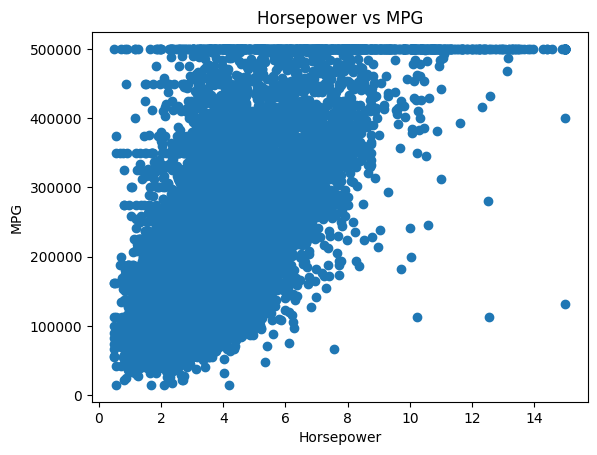

In [5]:
#Plot scatter graph
plt.scatter(X, Y)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.show()

In [6]:
#Add bias term
X = np.c_[np.ones(len(X)), X]

In [7]:
#Compute correlation
df[["median_income", "median_house_value"]].corr()

,median_income,median_house_value
median_income,1.000000,0.691871
median_house_value,0.691871,1.000000


In [8]:
#Calculate OLS weights
w = np.linalg.inv(X.T @ X) @ X.T @ Y

In [9]:
#Predict values
Y_pred = X @ w

In [10]:
#Compute residuals
residuals = Y - Y_pred

In [11]:
#Calculate SSE, MSE, R²
SSE = np.sum(residuals**2)
MSE = SSE / len(Y)
SST = np.sum((Y - np.mean(Y))**2)
R2 = 1 - (SSE / SST)
print("SSE =", SSE)
print("MSE =", MSE)
print("R² =", R2)

SSE = 119211472331544.8
MSE = 7012439548.9144
R² = 0.478684932375828


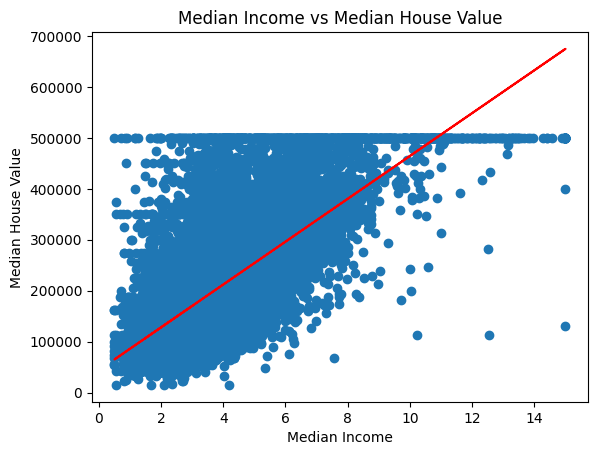

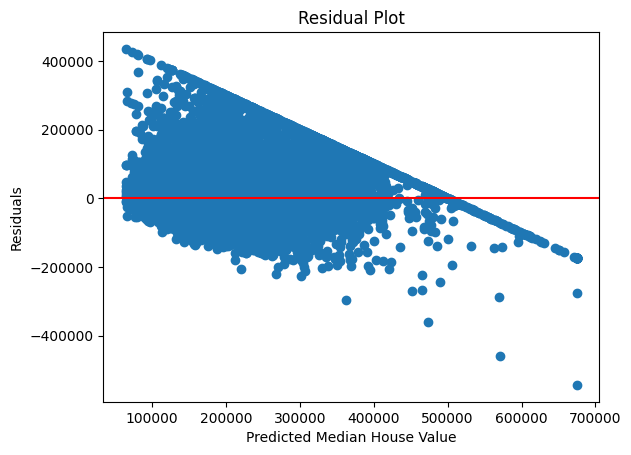

In [12]:
#Plot regression and residual graphs
plt.scatter(X[:, 1], Y)
plt.plot(X[:, 1], Y_pred, color="red")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()

plt.scatter(Y_pred, residuals)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Median House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()